In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 500)

## We'll pick up where the data understanding ended


In [6]:
df = pd.read_csv('mushrooms.csv')

In [7]:
df.head(10)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,e,c,s,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,e,c,s,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,e,e,s,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,e,c,s,s,w,w,p,w,o,p,k,s,m


In [8]:
df.shape

(8124, 23)

In [9]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,2,5,4,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,t,b,s,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,3776,5176,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [10]:
df.dtypes

class                       str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object

In [11]:
df.isna().sum().sum()

np.int64(0)

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df["class"].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

# Distribution of the Target Variable:

<Axes: xlabel='class', ylabel='count'>

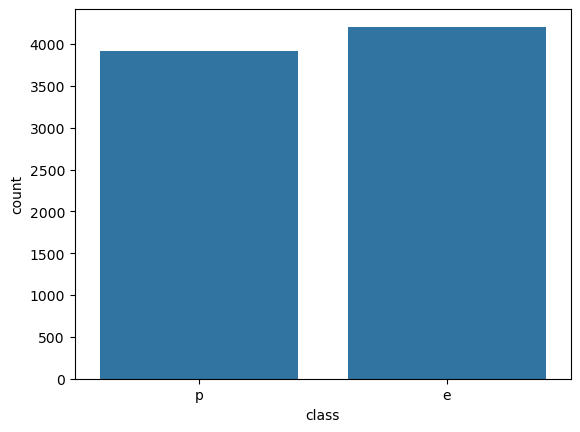

In [14]:
sns.countplot(x='class', data=df)

We notice that our dataset is relatively Balencedd with an almost 50/50 distribution between the two classes e/p

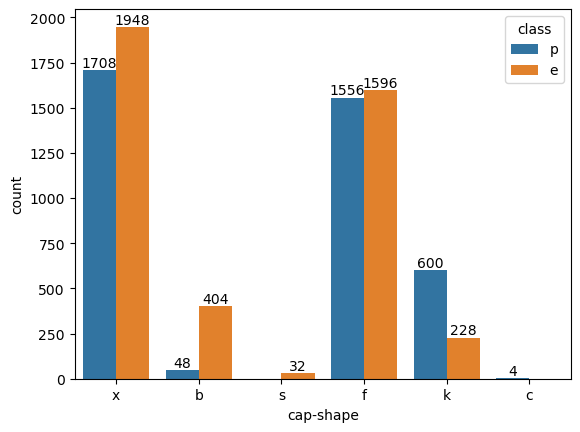

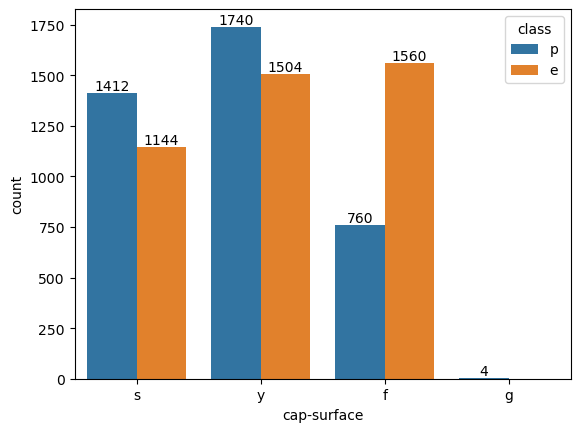

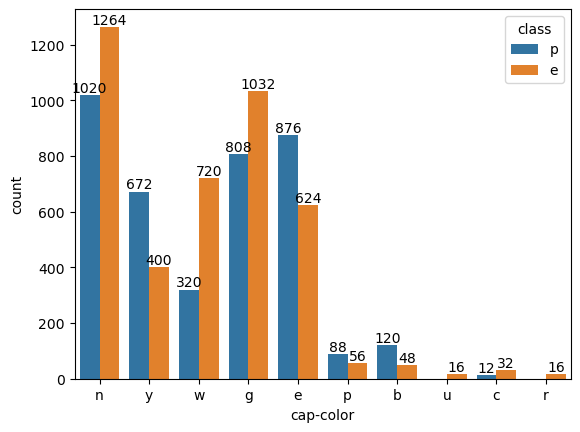

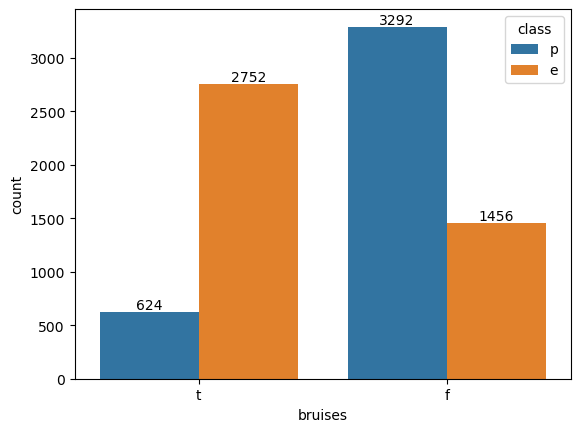

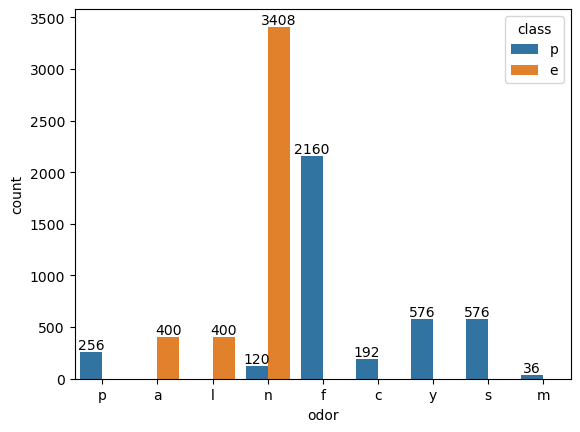

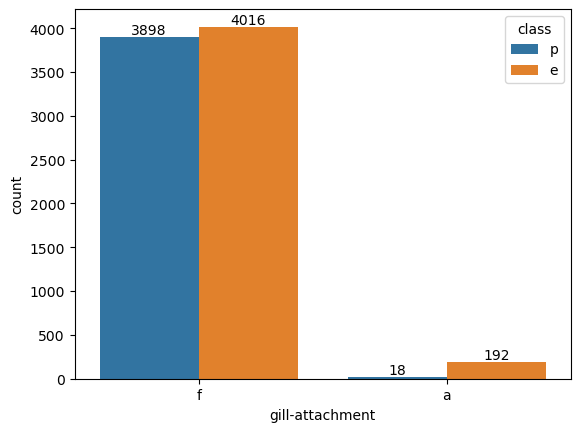

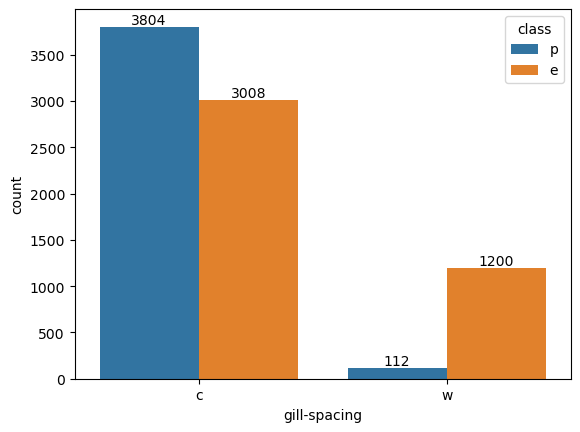

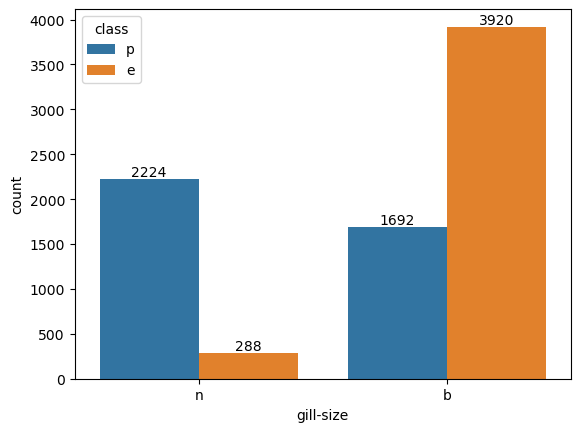

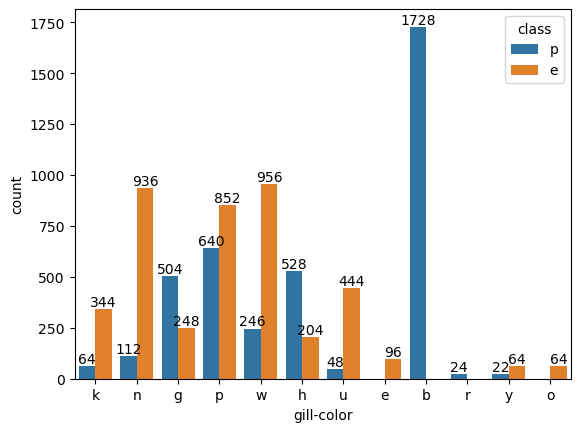

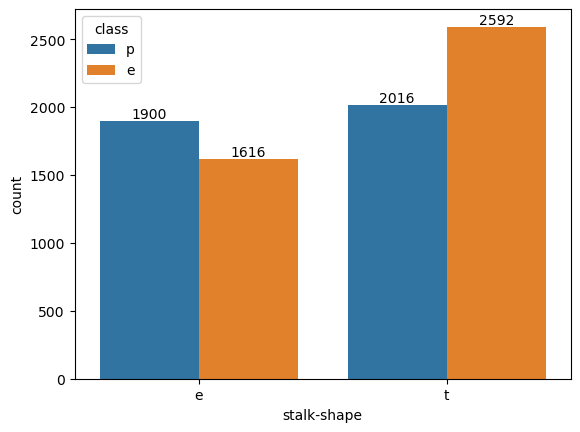

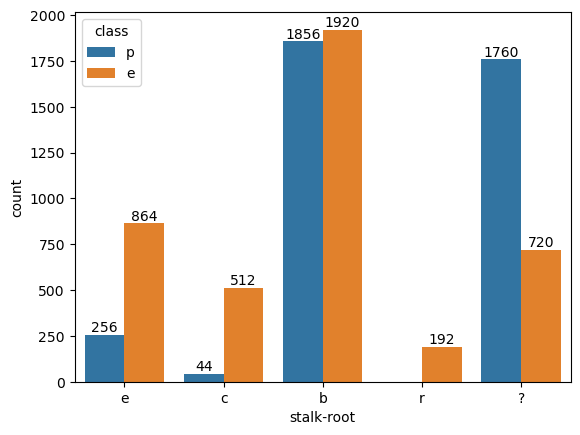

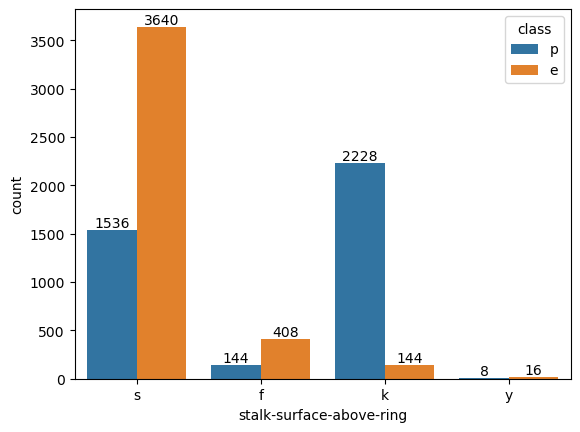

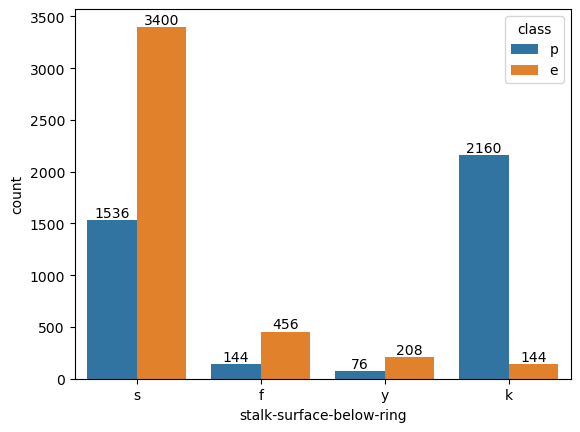

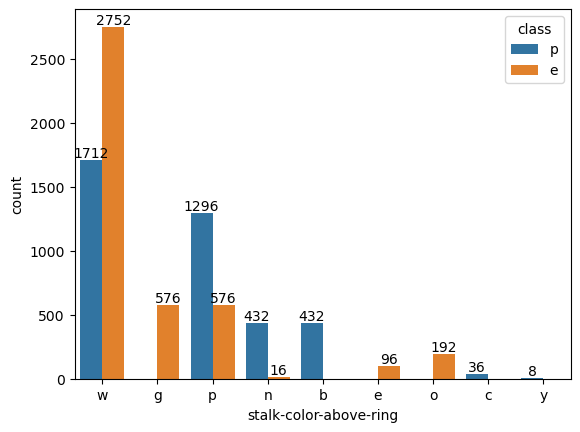

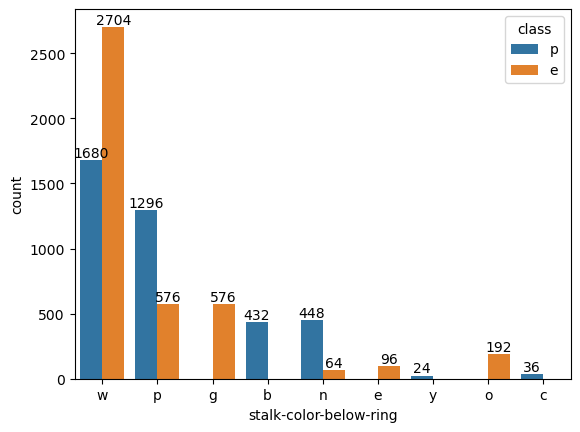

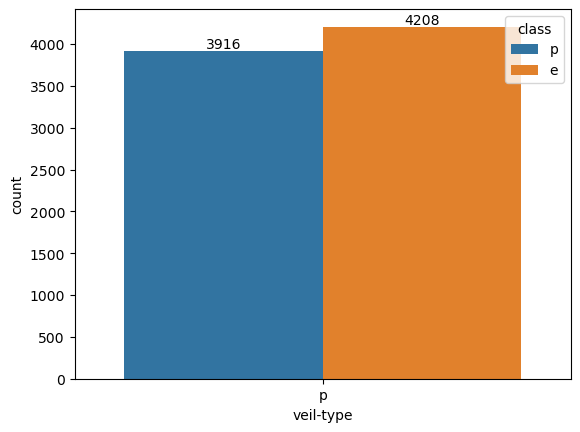

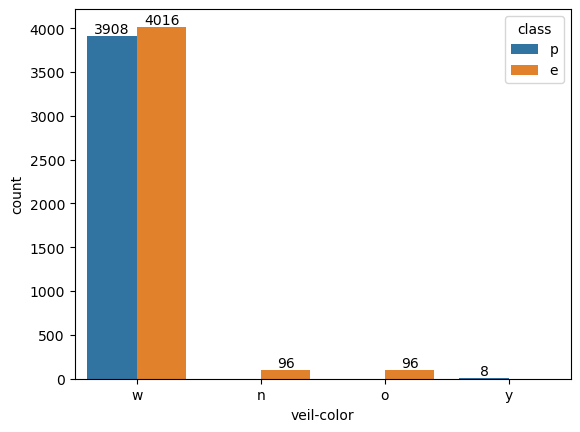

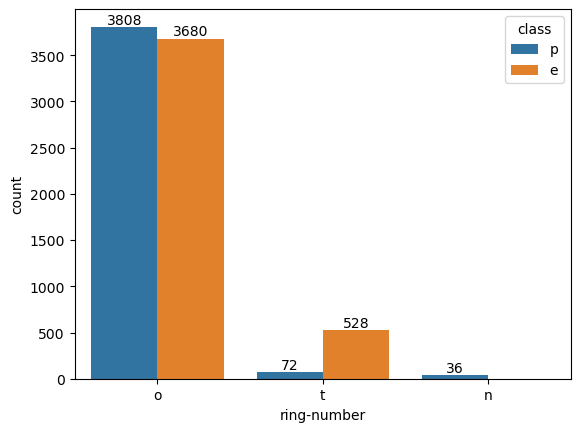

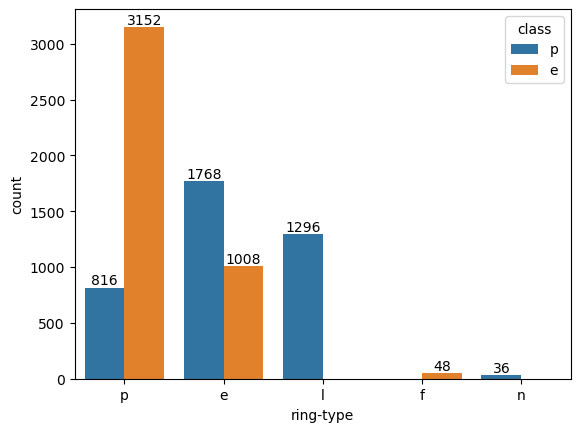

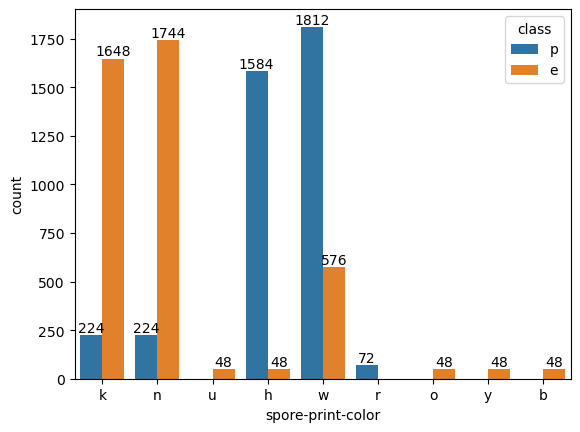

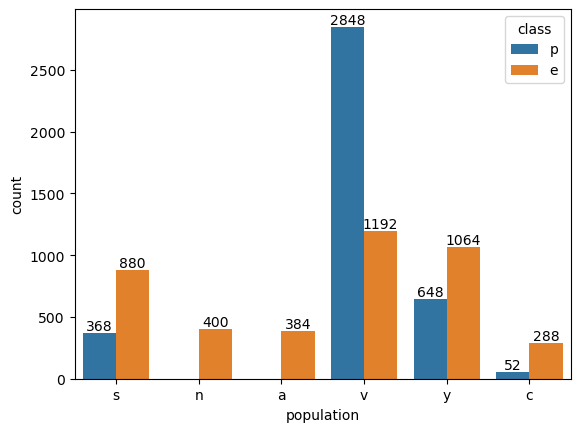

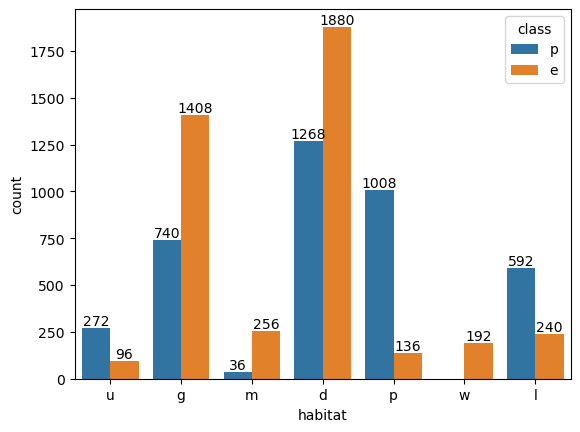

In [15]:
for column in df.columns:
    if column == 'class':
        pass
    else:
        t = sns.countplot(x=column, data=df, hue='class')
        for container in t.containers:
            t.bar_label(container)
        plt.show()

# Obsevations from Countplot with class hue:


odor: strongest feature, f almost always poisonous, n mostly edible
gill-size: n mostly poisonous, b mostly edible
bruises: presence of bruises linked to edible mushrooms
ring-type: l mostly poisonous, p mostly edible
spore-print-color: h and w mostly poisonous, k and n mostly edible

veil-type: only one unique value, will be dropped in Phase 3
Several neglectable values found in: cap-shape, cap-color, gill-attachment, veil-color, ring-number

Missing Data:
stalk-root: contains ? values (2480)

Class Distribution:

Dataset is well balanced: 4208 edible, 3916 poisonous

Conclusion:

odor, gill-size, spore-print-color and ring-type str important features

In [16]:
df["stalk-root"].value_counts()

stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64